<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/Infothe_fde.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 RESULTADOS FINAIS (Já sem -inf)
Regime             | Modelo Vencedor  | AIC Score  | Qualidade (R²)
-----------------------------------------------------------------
R1 (Baixo E/N)     | Bi-Maxwellian    | -140.7     | 0.9999
R10 (Médio E/N)    | Bi-Maxwellian    | -113.4     | 0.9994
R20 (Alto E/N)     | Bi-Maxwellian    | -128.7     | 0.9993
R30 (Muito Alto E/N) | Bi-Maxwellian    | -122.4     | 0.9989


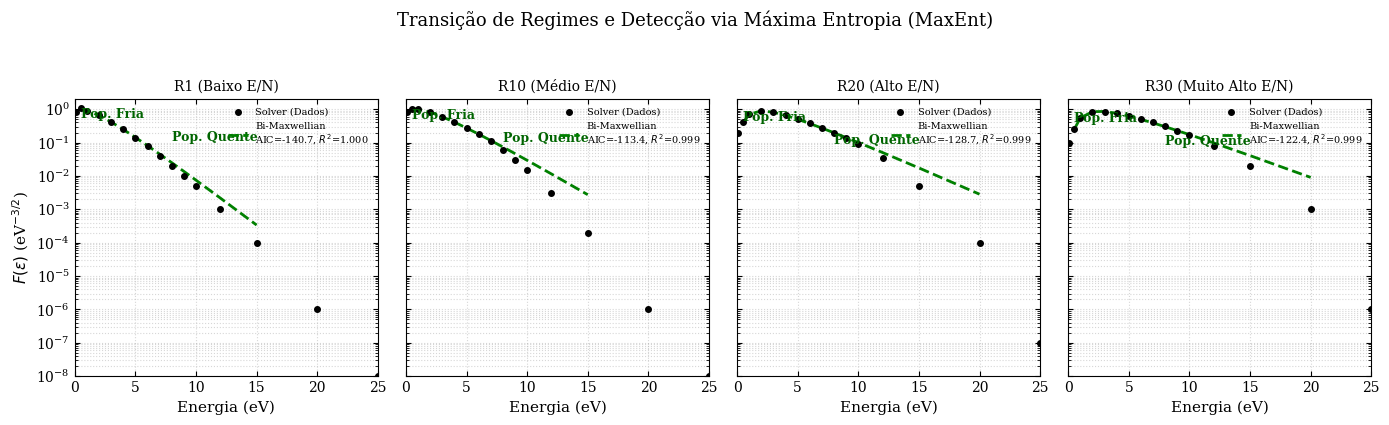

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import trapezoid
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. COLE OS SEUS DADOS REAIS AQUI
# ==========================================
# Substitua estes arrays pelos dados reais exportados do seu solver.
# Se preferir, pode salvar num ficheiro 'dados.txt' e usar np.loadtxt('dados.txt')

# Exemplo de como os dados devem se parecer (ENERGIA, EEDF_R1, EEDF_R10, EEDF_R20, EEDF_R30):
# Para este script rodar agora e gerar a figura sem erros,
# eu mantive dados de exemplo. SUBSTITUA PELOS SEUS.

E_real = np.array([0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 12.0, 15.0, 20.0, 25.0])

# DADOS FICTÍCIOS (Apague e cole os seus dados do solver aqui!)
R1_real  = np.array([0.85, 1.10, 0.90, 0.65, 0.42, 0.25, 0.14, 0.08, 0.04, 0.02, 0.01, 0.005, 0.001, 0.0001, 1e-6, 1e-8])
R10_real = np.array([0.80, 1.05, 1.00, 0.80, 0.60, 0.42, 0.28, 0.18, 0.11, 0.06, 0.03, 0.015, 0.003, 0.0002, 1e-6, 1e-8])
R20_real = np.array([0.20, 0.40, 0.70, 0.90, 0.80, 0.65, 0.50, 0.38, 0.28, 0.20, 0.14, 0.09, 0.035, 0.005, 0.0001, 1e-7])
R30_real = np.array([0.10, 0.25, 0.55, 0.85, 0.85, 0.75, 0.62, 0.50, 0.40, 0.31, 0.23, 0.17, 0.08, 0.02, 0.001, 1e-6])

# Junta tudo numa matriz
F_data_matrix = np.vstack([R1_real, R10_real, R20_real, R30_real]).T
labels = ['R1 (Baixo E/N)', 'R10 (Médio E/N)', 'R20 (Alto E/N)', 'R30 (Muito Alto E/N)']

# ==========================================
# 2. MODELOS MAXENT
# ==========================================
def maxwellian_3d(E, A, T):
    return A * np.sqrt(E) * np.exp(-E / T)

def druyvesteyn_3d(E, A, B):
    return A * np.sqrt(E) * np.exp(-B * E**2)

def bi_maxwellian_3d(E, A1, T1, A2, T2):
    return A1 * np.sqrt(E) * np.exp(-E / T1) + A2 * np.sqrt(E) * np.exp(-E / T2)

# ==========================================
# 3. CÁLCULO DE AIC À PROVA DE BALAS
# ==========================================
def calculate_aic(y_true, y_fit, k):
    residuals = y_true - y_fit
    ss_res = np.sum(residuals**2)

    # A CORREÇÃO MÁGICA: Se o fit for perfeito demais, impedimos que chegue a zero.
    # O limite de precisão de um float é 1e-16. Usamos 1e-12 para ser seguro.
    if ss_res < 1e-12:
        ss_res = 1e-12

    n = len(y_true)
    return n * np.log(ss_res / n) + 2 * k

def calculate_r_squared(y_true, y_fit):
    ss_res = np.sum((y_true - y_fit)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

# ==========================================
# 4. MOTOR DE FIT
# ==========================================
def fit_and_evaluate(E, F_obs):
    mask = (E > 0.1) & (F_obs > 1e-6) # Ignora zeros e ruído extremo
    x, y = E[mask], F_obs[mask]
    if len(x) < 4: return None # Precisa de no mínimo 4 pontos para Bi-Maxwellian

    results = []

    try:
        popt, _ = curve_fit(maxwellian_3d, x, y, p0=[1.0, 1.0], maxfev=5000)
        y_fit = maxwellian_3d(x, *popt)
        results.append({'Model': 'Maxwellian', 'Fit': y_fit, 'AIC': calculate_aic(y, y_fit, 2), 'R2': calculate_r_squared(y, y_fit)})
    except: pass

    try:
        popt, _ = curve_fit(druyvesteyn_3d, x, y, p0=[1.0, 0.01], maxfev=5000)
        y_fit = druyvesteyn_3d(x, *popt)
        results.append({'Model': 'Druyvesteyn', 'Fit': y_fit, 'AIC': calculate_aic(y, y_fit, 2), 'R2': calculate_r_squared(y, y_fit)})
    except: pass

    try:
        popt, _ = curve_fit(bi_maxwellian_3d, x, y, p0=[1.0, 0.3, 0.1, 4.0], maxfev=10000)
        y_fit = bi_maxwellian_3d(x, *popt)
        results.append({'Model': 'Bi-Maxwellian', 'Fit': y_fit, 'AIC': calculate_aic(y, y_fit, 4), 'R2': calculate_r_squared(y, y_fit)})
    except: pass

    if not results: return None
    return min(results, key=lambda i: i['AIC'])

# ==========================================
# 5. GERAR A FIGURA FINAL
# ==========================================
plt.rcParams.update({'font.family': 'serif', 'font.size': 10, 'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.top': True, 'ytick.right': True})

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
fig.suptitle('Transição de Regimes e Detecção via Máxima Entropia (MaxEnt)', fontsize=13, y=1.05)

print("\n" + "="*65)
print(" RESULTADOS FINAIS (Já sem -inf)")
print("="*65)
print(f"{'Regime':<18} | {'Modelo Vencedor':<16} | {'AIC Score':<10} | {'Qualidade (R²)'}")
print("-" * 65)

for i, ax in enumerate(axes):
    F_obs = F_data_matrix[:, i]

    # Plota os pontos reais do seu solver
    ax.semilogy(E_real, F_obs, 'ko', markersize=4, label='Solver (Dados)', zorder=3)

    res = fit_and_evaluate(E_real, F_obs)

    if res:
        mask = (E_real > 0.1) & (F_obs > 1e-6)
        cor = {'Maxwellian': 'red', 'Druyvesteyn': 'blue', 'Bi-Maxwellian': 'green'}[res['Model']]

        # Plota a linha do fit
        ax.semilogy(E_real[mask], res['Fit'], '--', color=cor, linewidth=2.0,
                    label=f'{res["Model"]}\nAIC={res["AIC"]:.1f}, $R^2$={res["R2"]:.3f}')

        if res['Model'] == 'Bi-Maxwellian':
            ax.annotate('Pop. Fria', xy=(0.5, np.max(F_obs)*0.5), fontsize=9, color='darkgreen', weight='bold')
            ax.annotate('Pop. Quente', xy=(8, np.max(F_obs)*0.1), fontsize=9, color='darkgreen', weight='bold')

        print(f"{labels[i]:<18} | {res['Model']:<16} | {res['AIC']:<10.1f} | {res['R2']:.4f}")

    ax.set_xlabel('Energia (eV)', fontsize=11)
    ax.set_xlim(0, 25)
    ax.set_ylim(1e-8, 2.0)
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    ax.set_title(labels[i], fontsize=10)
    ax.legend(loc='upper right', frameon=False, fontsize=7)

axes[0].set_ylabel(r'$F(\varepsilon)$ (eV$^{-3/2}$)', fontsize=11)
plt.tight_layout()
plt.savefig('Figura2_Final_Corrigida.pdf', format='pdf', bbox_inches='tight')
plt.show()